In [1]:
from espn_api.football import League
import pandas as pd


current_week = 14
import numpy as np
#print(np.__version__)
##print(np.__file__)
#print(hasattr(np, "matrix"))



In [ ]:

# Replace with your actual info
league_id = 619156725
year = 2025  # or 2025 if it's set up for next season
espn_s2 = 'AEBSrahjPMfdLGpD6sDc6kYq3PVfwNcUX46fVlDTk9hgw4l%2BBaEvie%2BYxliYSwdMx9r0jWxAV7YA7KA5lftZr8NRjm9BZYkSOcwfz9e34lo0ZNPKjTrDLokpQSkmshPp96vgIBVeCazTCjkeYP%2BjBHCT3m85oxljPJ8JKOLJvn%2F0ykoQwxgkQx1atCIalowLDw%2FdLwBNAOTGYm1qJwdLSdqc7e4R12lZfY7gLi2CN7a5soLmA8B%2FewuvyTZsHyRHWw4c8XWk4zmq2XdYKUDAS9844%2FTmWflMzOhkNBXpmlwdBg%3D%3D'  # Leave blank if public
swid = '{C00A8DB8-3E66-4AE6-AF3A-1CEFE7D634AE}'             # Leave blank if public

# Create the league object
league = League(league_id=league_id, year=year, espn_s2=espn_s2, swid=swid)

# === Print league settings ===
print("League Name:", league.settings.name)
#print("Number of Teams:", league.settings.size)

# === Print team rosters ===
# for team in league.teams:
#     print(f"\nTeam: {team.team_name} | Abbreviation: {team.team_abbrev} | Owner: {team.owners[0]['firstName']}")
#     for player in team.roster:
#         print(f"  {player.name} - {player.position} - {player.stats} pts")



League Name: $200 PPR, Auction Draft


In [ ]:
# league = League(league_id=league_id, year=2025, espn_s2=espn_s2, swid=swid)

# players_data = []

# # Loop through each team and player
# x=0
# for team in league.teams:
#     for player in team.roster:
#         if (x==0): 
#             print(player.stats[2]["points"])
#             # print(player.stats[1]["projected_points"])
#             # print(player.stats[2]["projected_points"])
#             x=1
#             print(player.name)
#         players_data.append({
#             'player_name': player.name,
#             'team': team.team_name
#         })

# # Create DataFrame with just player_name and team
# # df = pd.DataFrame(players_data, columns=['player_name', 'team'])

# # Save to CSV
# # df.to_csv("players_on_teams.csv", index=False)




In [ ]:


# # --- Init league ---
# league = League(league_id=league_id, year=2025, espn_s2=espn_s2, swid=swid)

# LINEUP_LIMITS = {"QB": 1, "RB": 2, "WR": 2, "TE": 1, "FLEX": 2}
# FLEX_ELIGIBLE = ["RB", "WR", "TE"]



# # --- Get box scores for week 2 ---

# for i in range(0,current_week):
#     week =i+1
#     results = []
#     box_scores = league.box_scores(week)
#     for match in box_scores:
#         for team, lineup in [(match.home_team, match.home_lineup),
#                             (match.away_team, match.away_lineup)]:
            
#             starters, bench = [], []
            
#             for p in lineup:
#                 points = p.points
#                 slot = p.slot_position   # lineup slot **that week**
#                 pos = p.position         # actual position (QB, RB, etc.)
                
#                 if slot in ["BE", "IR"]:
#                     bench.append((p.name, pos, points))
#                 else:
#                     starters.append((p.name, pos, points))
            
#             # --- Actual starter points ---
#             actual_points = sum(p[2] for p in starters)
            
#             # --- Optimal lineup ---
#             all_players = starters + bench
#             used, optimal_points = [], 0

#             # QB
#             qbs = sorted([p for p in all_players if p[1] == "QB"], key=lambda x: x[2], reverse=True)
#             if qbs:
#                 used.append(qbs[0]); optimal_points += qbs[0][2]

#             # RB
#             rbs = sorted([p for p in all_players if p[1] == "RB"], key=lambda x: x[2], reverse=True)[:2]
#             used.extend(rbs); optimal_points += sum(p[2] for p in rbs)

#             # WR
#             wrs = sorted([p for p in all_players if p[1] == "WR"], key=lambda x: x[2], reverse=True)[:2]
#             used.extend(wrs); optimal_points += sum(p[2] for p in wrs)

#             # TE
#             tes = sorted([p for p in all_players if p[1] == "TE"], key=lambda x: x[2], reverse=True)
#             if tes:
#                 used.append(tes[0]); optimal_points += tes[0][2]

#             # FLEX (best 2 RB/WR/TE not already used)
#             flex_pool = [p for p in all_players if p[1] in FLEX_ELIGIBLE and p not in used]
#             flexes = sorted(flex_pool, key=lambda x: x[2], reverse=True)[:2]
#             used.extend(flexes); optimal_points += sum(p[2] for p in flexes)

#             accuracy = actual_points / optimal_points if optimal_points > 0 else 1

#             results.append({
#                 "week": week,
#                 "team": team.team_name,
#                 "actual_points": round(actual_points, 2),
#                 "optimal_points": round(optimal_points, 2),
#                 "accuracy": round(accuracy, 3)
#             })

#     df = pd.DataFrame(results)
#     df.to_csv(f"week{week}_Start_Sit.csv", index=False)
# print("done")


In [ ]:
# --- Init league ---
league = League(league_id=league_id, year=2025, espn_s2=espn_s2, swid=swid)

LINEUP_LIMITS = {"QB": 1, "RB": 2, "WR": 2, "TE": 1, "FLEX": 2}
FLEX_ELIGIBLE = ["RB", "WR", "TE"]



week = current_week
results = []
box_scores = league.box_scores(week)

for match in box_scores:
    team_results = []

    # --- Process both home & away teams ---
    for team, lineup, opp in [(match.home_team, match.home_lineup, match.away_team),
                        (match.away_team, match.away_lineup,match.home_team)]:
        
        starters, bench = [], []
        
        for p in lineup:
            points = p.points
            slot = p.slot_position   # lineup slot that week
            pos = p.position         # actual position (QB, RB, etc.)
            
            if slot in ["BE", "IR"]:
                bench.append((p.name, pos, points))
            else:
                starters.append((p.name, pos, points))
        
        # --- Actual starter points ---
        actual_points = sum(p[2] for p in starters)
        
        # --- Optimal lineup ---
        all_players = starters + bench
        used, optimal_points = [], 0

        # QB
        qbs = sorted([p for p in all_players if p[1] == "QB"], key=lambda x: x[2], reverse=True)
        if qbs:
            used.append(qbs[0]); optimal_points += qbs[0][2]

        # RB
        rbs = sorted([p for p in all_players if p[1] == "RB"], key=lambda x: x[2], reverse=True)[:2]
        used.extend(rbs); optimal_points += sum(p[2] for p in rbs)

        # WR
        wrs = sorted([p for p in all_players if p[1] == "WR"], key=lambda x: x[2], reverse=True)[:2]
        used.extend(wrs); optimal_points += sum(p[2] for p in wrs)

        # TE
        tes = sorted([p for p in all_players if p[1] == "TE"], key=lambda x: x[2], reverse=True)
        if tes:
            used.append(tes[0]); optimal_points += tes[0][2]

        # FLEX (best 2 RB/WR/TE not already used)
        flex_pool = [p for p in all_players if p[1] in FLEX_ELIGIBLE and p not in used]
        flexes = sorted(flex_pool, key=lambda x: x[2], reverse=True)[:2]
        used.extend(flexes); optimal_points += sum(p[2] for p in flexes)

        accuracy = actual_points / optimal_points if optimal_points > 0 else 1

        team_results.append({
            "week": week,
            "team": team.team_name,
            "opp": opp.team_name,
            "team_owner": team.owners[0]["firstName"] if team.owners else "Unknown",
            "actual_points": round(actual_points, 2),
            "optimal_points": round(optimal_points, 2),
            "accuracy": round(accuracy, 3),
        })

    # --- Now compare the two teams in this matchup ---
    t1, t2 = team_results

    # actual win
    t1["a_wins"] = int(t1["actual_points"] > t2["actual_points"])
    t2["a_wins"] = int(t2["actual_points"] > t1["actual_points"])

    # optimal vs opponent actual
    t1["op_wins"] = int(t1["optimal_points"] > t2["actual_points"])
    t2["op_wins"] = int(t2["optimal_points"] > t1["actual_points"])

    # optimal vs opponent optimal
    t1["op_op_wins"] = int(t1["optimal_points"] > t2["optimal_points"])
    t2["op_op_wins"] = int(t2["optimal_points"] > t1["optimal_points"])

    results.extend([t1, t2])

# --- Save weekly results ---
df = pd.DataFrame(results)
df = df.sort_values("actual_points", ascending=False).reset_index(drop=True)
df["med_wins"] = 0
df.loc[:5, "med_wins"] = 1
df["tot_wins"] = df["med_wins"] + df["a_wins"]
df.to_csv(f"week{week}_Start_Sit.csv", index=False)

print("✅ done")


✅ done


# Plots

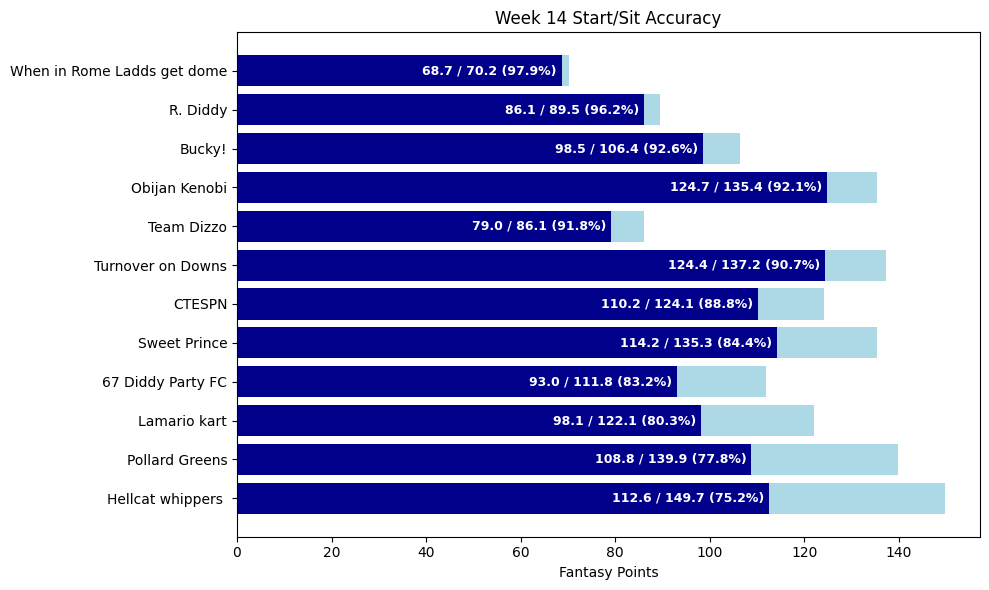

In [ ]:
import matplotlib.pyplot as plt

week_plot = 14
# Rebuild DataFrame directly (replace with your results variable if still in memory)


# Sort by accuracy (like Sleeper ranks)
df = pd.read_csv(f"week{week_plot}_Start_Sit.csv")
#print(df.columns)
#df = pd.read_csv("weekTotals.csv") #---------------------------------------- Comment out for weekly
df = df.sort_values("accuracy", ascending=False).reset_index(drop=True)


# --- Sleeper-style plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Background = optimal points
ax.barh(df["team"], df["optimal_points"], color="lightblue")

# Foreground = actual points
ax.barh(df["team"], df["actual_points"], color="darkblue")

# Text labels
for i, row in df.iterrows():
    label = f"{row['actual_points']:.1f} / {row['optimal_points']:.1f} ({row['accuracy']*100:.1f}%)"
    ax.text(row["actual_points"] - 1, i, label,
            va="center", ha="right", color="white", fontsize=9, fontweight="bold")

# Styling
ax.set_xlabel("Fantasy Points")
ax.set_title(f"Week {week_plot} Start/Sit Accuracy")
ax.invert_yaxis()  # Highest accuracy at top

plt.tight_layout()
plt.savefig(f"week{week_plot}_plot.png", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:



all_dfs = []

# --- Load all weekly CSVs ---
for i in range(1, current_week + 1):
    df = pd.read_csv(f"week{i}_Start_Sit.csv")
    all_dfs.append(df)

# --- Combine all weeks ---
df_all = pd.concat(all_dfs, ignore_index=True)

latest_names = (
    all_dfs[-1][["team_owner", "team"]]  # take only current week
    .drop_duplicates("team_owner")       # keep one row per owner
    .set_index("team_owner")
)
# --- Aggregate by team ---
agg = (
    df_all.groupby("team_owner", as_index=False)
    .agg({
        "actual_points": "sum",
        "optimal_points": "sum",
        "a_wins": "sum",
        "op_wins" :"sum",
        "op_op_wins":"sum",
        "med_wins":"sum",
        "tot_wins":"sum"
    })
)
agg["team"] = agg["team_owner"].map(latest_names["team"])
# --- Compute accuracy ---
agg["accuracy"] = round(agg["actual_points"] / agg["optimal_points"],2)
agg["actual_points"] = round(agg["actual_points"],2)
agg["optimal_points"] = round(agg["optimal_points"],2)
agg["week"] = "total"  # season aggregate marker

# --- Reorder columns to match ---
agg = agg[["week","team","team_owner", "actual_points", "optimal_points", "accuracy","a_wins","op_wins","op_op_wins","med_wins","tot_wins"]]

# --- Save to CSV ---
#agg.sort_values(by="med_wins", inplace=True)
agg.to_csv("weekTotals.csv", index=False)

print("done")


done


In [ ]:
df = pd.read_csv("weekTotals.csv")
df.sort_values(by="op_op_wins", inplace=True, ascending=False)
df.to_csv("weekTotals.csv", index=False)

In [ ]:
df = pd.read_csv("weekTotals.csv")

# Sort by op_op_wins descending and reset rank numbers
leaderboard = df.sort_values(by="med_wins", ascending=False).reset_index(drop=True)

# Add Rank column starting at 1
leaderboard.insert(0, "Rank", leaderboard.index + 1)

print(leaderboard[["Rank", "team", "med_wins","tot_wins"]])

    Rank                         team  med_wins  tot_wins
0      1                Obijan Kenobi        10        15
1      2               Pollard Greens         9        18
2      3                 Lamario kart         8        16
3      4                       Bucky!         8        16
4      5                 Sweet Prince         8        16
5      6                       CTESPN         7        14
6      7            Hellcat whippers          7        12
7      8            Turnover on Downs         6        15
8      9  When in Rome Ladds get dome         6        13
9     10                   Team Dizzo         6        11
10    11            67 Diddy Party FC         5        12
11    12                     R. Diddy         4        10


In [ ]:
df_list = []

for w in range(1, 15):
    filename = f"week{w}_Start_Sit.csv"
    
    # Load CSV
    df = pd.read_csv(filename)
    
    # Add or overwrite week column
    df["week"] = w
    
    df_list.append(df)

# Concatenate all weeks
concat_df = pd.concat(df_list, ignore_index=True)


df = concat_df.sort_values(["week", "actual_points"], ascending=[True, False])

# Compute partial wins
def compute_partial_wins(group):
    group = group.sort_values("actual_points", ascending=False)
    group["rank"] = range(1, len(group) + 1)
    group["partial_win"] = (len(group) - group["rank"]) / (len(group) - 1)
    return group

df = df.groupby("week").apply(compute_partial_wins).reset_index(drop=True)

# Expected weekly wins = median win + partial win
df["expected_wins"] = df["med_wins"] + df["partial_win"]

# Aggregate over the season
season_expected = (
    df.groupby("team")["expected_wins"]
    .sum()
    .reset_index()
    .rename(columns={"expected_wins_week": "expected_wins_total"})
)

print(season_expected)
season_expected.to_csv("expectedWins.csv")

                           team  expected_wins
0             67 Diddy Party FC      12.000000
1      Benson Boon make it Boom       0.909091
2                        Bucky!       7.909091
3                       Bucky🚒🤕       8.818182
4                        CTESPN      14.000000
5             Cees get Deegrees       7.545455
6           Chubbas Bubble Butt       0.454545
7          Gibby is monty's son       3.363636
8             Hellcat whippers        3.818182
9                  Lamario kart       2.181818
10                Obijan Kenobi      18.181818
11                Perc poppers        9.818182
12               Pollard Greens      17.363636
13                     R. Diddy       8.090909
14   Skaterboy and Travis Swift       4.000000
15       Stat Paddford my goat        0.000000
16                 Sweet Prince      15.272727
17           Tanking for CeeDee       5.545455
18                   Team Dizzo      12.636364
19            Turnover on Downs      12.909091
20  When in R

C:\Users\scwvi\AppData\Local\Temp\ipykernel_14976\3238095524.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("week").apply(compute_partial_wins).reset_index(drop=True)


| Team                           | Expected Wins |
|--------------------------------|---------------|
| Obijan Kenobi                 | 18.18181818   |
| Pollard Greens                 | 17.36363636   |
| Bucky!                         | 16.72727273   |
| Sweet Prince                   | 15.27272727   |
| Lamario kart                   | 15.27272727   |
| CTEPSPN                        | 14            |
| Perc poppers                   | 13.63636364   |
| Turnover on Downs              | 12.90909091   |
| Team Dizzo                     | 12.63636364   |
| 67 Diddy Party FC              | 12            |
| When in Rome Ladds get dome    | 11.90909091   |
| R. Diddy                       | 8.090909091   |


# Expected wins per team
67 Diddy Party FC    11 <br>
Gibby is monty's son 8.727272<br>
Bucky🚒🤕           14.363637<br>
CTESPN               8.545455<br>
Cees get Deegrees    13.09091<br>
Obijan Kenobi        14.000000<br>
Perc poppers         9.818182<br>
Pollard Greens       15.272727<br>
R. Diddy             6.272727<br>
Sweet Prince         9.818182<br>
Team Dizzo           10.545455<br>
Turnover on Downs    10.545455<br>

In [ ]:
# data = {
#     "Team": [
#         "67 Diddy Party FC",
#         "Gibby is monty's son",
#         "Bucky🚒🤕",
#         "CTESPN",
#         "Cees get Deegrees",
#         "Obijan Kenobi",
#         "Perc poppers",
#         "Pollard Greens",
#         "R. Diddy",
#         "Sweet Prince",
#         "Team Dizzo",
#         "Turnover on Downs"
#     ],
#     "Expected Wins": [
#         11,
#         8.727272,
#         14.363637,
#         8.545455,
#         13.09091,
#         14.0,
#         9.818182,
#         15.272727,
#         6.272727,
#         9.818182,
#         10.545455,
#         10.545455
#     ]
# }

# df = pd.DataFrame(data)
# df["seasonProjected"] = round(df["Expected Wins"]*(14/11),2)
# df["Expected Wins"] = round(df["Expected Wins"],2)
# df = df.sort_values(by="Expected Wins", ascending=False).reset_index(drop=True)
# print(df)



In [ ]:
all_diffs = []  # store all weeks' differentials
week_list = []  # optional: track which week each diff belongs to
scoring = []

for i in range(1, 14):
    box_scores = league.box_scores(i)
    
    for match in box_scores:

        # actual fantasy points for home & away
        home_points = match.home_team.projected_total_points if match.home_team is None else match.home_score
        away_points = match.away_team.projected_total_points if match.away_team is None else match.away_score

        # If ESPN API gives None, fall back to sum of lineup points
        if home_points is None:
            home_points = sum(p.points for p in match.home_lineup)
        if away_points is None:
            away_points = sum(p.points for p in match.away_lineup)
        scoring.append(home_points)
        scoring.append(away_points)
        # absolute point differential
        diff = abs(home_points - away_points)
        all_diffs.append(diff)
        week_list.append(i)  # optional: keep week info

# Build final DataFrame



In [ ]:
df_diff = pd.DataFrame({"Week": week_list, "Diff": all_diffs})

avgpts = round(sum(scoring)/len(scoring),10)
scoring_sort = sorted(scoring)
median = (scoring_sort[len(scoring_sort)//2]+scoring_sort[(len(scoring_sort)//2)+1])/2
print((df_diff["Diff"].mean()))
print((df_diff["Diff"].median()))
print((df_diff["Diff"] > 5).sum())
print((df_diff["Diff"] <= 5).sum())
print((df_diff["Diff"] > 15).sum())
print((df_diff["Diff"] <= 15).sum())
print(avgpts)
print(median)


23.43410256410256
17.160000000000004
60
18
43
35
109.0155128205
109.21
